In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from matplotlib.ticker import MaxNLocator
from matplotlib import rcParams
from matplotlib.colors import LogNorm
import matplotlib
matplotlib.use('TkAgg')
rcParams['axes.labelsize'] = 9
rcParams['xtick.labelsize'] = 9
rcParams['ytick.labelsize'] = 9
rcParams['legend.fontsize'] = 9
rcParams['font.family'] = 'sans-serif'
#rcParams['font.sans-serif'] = ['Helvetica']
rcParams['grid.color'] = 'k'
rcParams['grid.linewidth'] = 0.2
my_locator = MaxNLocator(6)
singlecolsize = (3.3522420091324205, 2.0717995001590714)
doublecolsize = (7.100005949910059, 4.3880449973709)


In [18]:
df = pd.read_csv("table_group_params.csv")

In [19]:
rproj_fit_mult=df.rproj_fit_mult.to_numpy()
vproj_fit_mult=df.vproj_fit_mult.to_numpy()
vproj_fit_offset=df.vproj_fit_offset.to_numpy()
gdrproj_fit_mult=df.gd_rproj_fit_mult.to_numpy()
gdvproj_fit_mult=df.gd_vproj_fit_mult.to_numpy()
gdvproj_fit_offset=df.gd_vproj_fit_offset.to_numpy()
labels=["({a:d},{b:d},{c:d},{d:d},{e:d},{f:d})".format(a=rproj_fit_mult[ii], b=vproj_fit_mult[ii], c=vproj_fit_offset[ii], d=gdrproj_fit_mult[ii], e=gdvproj_fit_mult[ii], f=gdvproj_fit_offset[ii]) for ii in range(0,len(df))]
labels_for_giant_params=["({a:d}, {b:d}, {c:d})".format(a=rproj_fit_mult[ii], b=vproj_fit_mult[ii], c=vproj_fit_offset[ii]) for ii in range(0,len(df))]
df.loc[:,'labels_giant_params']=labels_for_giant_params

In [20]:
giantresults = df.groupby('labels_giant_params').median()
giantresults=giantresults[(giantresults.rproj_fit_mult>1)&(giantresults.vproj_fit_mult>1)]

In [21]:
giantresults

,rproj_fit_mult,vproj_fit_mult,vproj_fit_offset,gd_rproj_fit_mult,gd_vproj_fit_mult,gd_vproj_fit_offset,mu_HME,mu_HME_dyn,mu_HME_HAMngt7,P_G,...,mu_HME_dw,P_G_dw,C_G_dw,P_H_dw,C_H_dw,P_G_dwgt1,C_G_dwgt1,P_H_dwgt1,C_H_dwgt1,mu_HME_dwgt1
labels_giant_params,,,,,,,,,,,,,,,,,,,,,
"(2, 2, 100)",2.0,2.0,100.0,3.5,3.5,150.0,0.163000,0.221737,0.200000,0.993128,...,0.165000,0.999485,0.877291,0.991280,0.942996,0.982403,0.956852,0.955007,0.961822,0.144000
"(2, 2, 200)",2.0,2.0,200.0,3.5,3.5,150.0,0.161000,0.224871,0.204000,0.992725,...,0.163000,0.999478,0.883504,0.991579,0.945327,0.982096,0.959737,0.956665,0.964669,0.147513
"(2, 2, 300)",2.0,2.0,300.0,3.5,3.5,150.0,0.161000,0.237029,0.197000,0.992282,...,0.163000,0.999474,0.887354,0.991682,0.946022,0.981938,0.958648,0.956317,0.963731,0.148020
"(2, 3, 100)",2.0,3.0,100.0,3.5,3.5,150.0,0.161167,0.237029,0.204000,0.992837,...,0.163505,0.999415,0.883649,0.991604,0.944458,0.980426,0.959347,0.953850,0.964380,0.148000
"(2, 3, 200)",2.0,3.0,200.0,3.5,3.5,150.0,0.161000,0.240184,0.197000,0.992502,...,0.162003,0.999474,0.888468,0.991758,0.946048,0.982174,0.959912,0.956880,0.964941,0.151000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"(6, 5, 200)",6.0,5.0,200.0,3.5,3.5,150.0,0.205000,0.870974,0.476305,0.956522,...,0.209000,0.984387,0.978342,0.956130,0.988553,0.845354,0.986575,0.706861,0.988550,0.275000
"(6, 5, 300)",6.0,5.0,300.0,3.5,3.5,150.0,0.207000,0.909256,0.494000,0.954467,...,0.212000,0.983375,0.979277,0.954144,0.989175,0.839171,0.986789,0.699940,0.989482,0.278623
"(6, 6, 100)",6.0,6.0,100.0,3.5,3.5,150.0,0.204000,0.870211,0.475000,0.957871,...,0.208000,0.984404,0.976474,0.956400,0.987474,0.844768,0.984177,0.707373,0.987234,0.275000


In [22]:
giantmaxs=df.groupby('labels_giant_params').max()
giantmins = df.groupby('labels_giant_params').min()

In [23]:
giantrangedf = giantmaxs-giantmins

In [24]:
giantrangedf

,rproj_fit_mult,vproj_fit_mult,vproj_fit_offset,gd_rproj_fit_mult,gd_vproj_fit_mult,gd_vproj_fit_offset,mu_HME,mu_HME_dyn,mu_HME_HAMngt7,P_G,...,mu_HME_dw,P_G_dw,C_G_dw,P_H_dw,C_H_dw,P_G_dwgt1,C_G_dwgt1,P_H_dwgt1,C_H_dwgt1,mu_HME_dwgt1
labels_giant_params,,,,,,,,,,,,,,,,,,,,,
"(1, 1, 100)",0,0,0,5,5,300,1.000000e-03,0.000000,0.000000,0.000022,...,0.001182,0.000000,0.004544,0.000000,0.003006,0.000000,0.017686,0.000981,0.022674,0.003000
"(1, 1, 200)",0,0,0,5,5,300,1.000000e-03,0.000000,0.000000,0.000021,...,0.001000,0.000000,0.004241,0.000000,0.002781,0.000000,0.021229,0.000734,0.026572,0.007000
"(1, 1, 300)",0,0,0,5,5,300,1.000000e-03,0.000000,0.000000,0.000017,...,0.001000,0.000000,0.003400,0.000000,0.002190,0.000000,0.009703,0.001127,0.015970,0.041684
"(1, 2, 100)",0,0,0,5,5,300,1.000000e-03,0.000000,0.000000,0.000022,...,0.001000,0.000000,0.004615,0.000000,0.003016,0.000000,0.017686,0.000834,0.022966,0.004000
"(1, 2, 200)",0,0,0,5,5,300,1.693090e-15,0.000000,0.000000,0.000023,...,0.001000,0.000000,0.004666,0.000000,0.003027,0.000000,0.023221,0.000906,0.028590,0.012243
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"(6, 5, 200)",0,0,0,5,5,300,7.000000e-03,0.000929,0.000844,0.004306,...,0.007701,0.004648,0.026191,0.010420,0.013393,0.018624,0.026856,0.026382,0.020923,0.004000
"(6, 5, 300)",0,0,0,5,5,300,7.000000e-03,0.030477,0.000000,0.004289,...,0.007000,0.004163,0.024695,0.009119,0.012557,0.018586,0.023761,0.023778,0.020070,0.003000
"(6, 6, 100)",0,0,0,5,5,300,7.000000e-03,0.002340,0.000000,0.005249,...,0.008000,0.005353,0.029812,0.011995,0.015462,0.017254,0.027782,0.028555,0.022901,0.005012


# Lollipop chart for selecting dwarf-association parameters

In [25]:
pg=giantresults.P_G.to_numpy()
cg=giantresults.C_G.to_numpy()
ph=giantresults.P_H.to_numpy()
ch=giantresults.C_H.to_numpy()
mu_phys=giantresults.mu_HME.to_numpy()
mu=giantresults.mu_HME.to_numpy()#/np.median(giantresults.mu_HME.to_numpy())
fn=interp1d([np.max(mu),np.min(mu)],[0.7,1])
mu=fn(mu)
mu_dyn=giantresults.mu_HME_dyn.to_numpy()
mu_dyn_rank = interp1d([np.max(mu_dyn),np.min(mu_dyn)],[0.7,1])(mu_dyn)
#mu=1-rankdata(mu,'max')/len(x)
pgtimescg=pg*cg
phtimesch=ph*ch
pgrange=giantrangedf.P_G.to_numpy()
cgrange=giantrangedf.C_G.to_numpy()
phrange=giantrangedf.P_H.to_numpy()
chrange=giantrangedf.C_H.to_numpy()
mu_physrange=giantrangedf.mu_HME.to_numpy()

order=np.argsort(pgtimescg)
pg=pg[order]
cg=cg[order]
ch=ch[order]
ph=ph[order]
mu=mu[order]
mu_dyn=mu_dyn[order]
mu_dyn_rank=mu_dyn_rank[order]
mu_phys=mu_phys[order]
phtimesch=phtimesch[order]
pgtimescg=pgtimescg[order]
pgrange=pgrange[order]
cgrange=cgrange[order]
phrange=phrange[order]
chrange=chrange[order]
newlabels=np.array(giantresults.index.to_numpy())[order]

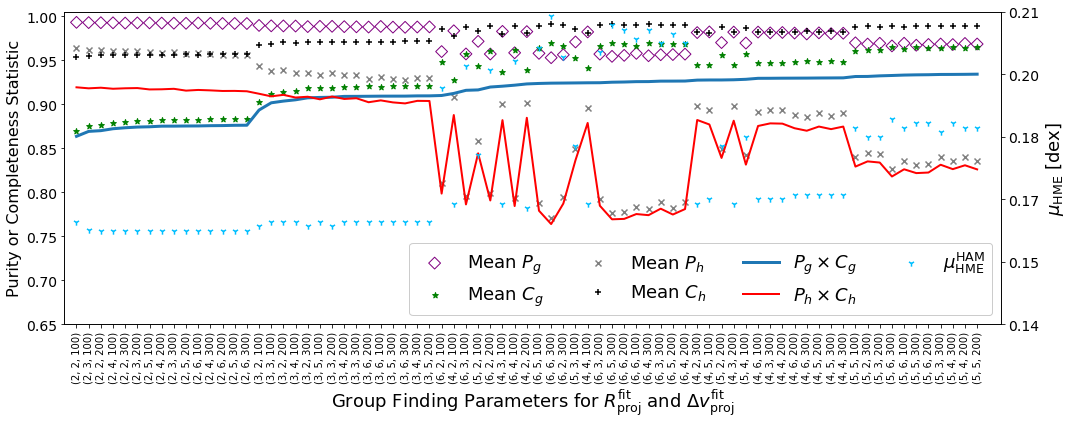

In [50]:
myrange=np.arange(1,len(pg)+1)
fig,ax=plt.subplots(figsize=(15,6))
ax.scatter(myrange-1,pg,edgecolors='purple',facecolors='None',marker='D',label='Mean $P_g$',s=70)
ax.scatter(myrange-1,cg,color='green',marker='*', label='Mean $C_g$')
ax.scatter(myrange-1,ph,color='gray',marker='x', label='Mean $P_h$')
ax.scatter(myrange-1,ch,color='k',marker='+', label='Mean $C_h$',s=30)
ax.plot(myrange-1,pgtimescg,color='tab:blue', linewidth=3,label=r'$P_g \times C_g$')
ax.plot(myrange-1,phtimesch,color='red',linewidth=2, label=r'$P_h \times C_h$')
ax.set_xticks(myrange-1,newlabels, rotation='vertical',fontsize=10)
ax.set_xlabel(r"Group Finding Parameters for $R_{\rm proj}^{\rm fit}$ and $\Delta v_{\rm proj}^{\rm fit}$",\
              fontsize=18)
ax.set_ylim(0.65,1.005)
ytvals = np.arange(0.65,1.05,0.05)
ax.set_yticks(ytvals, ["{:0.2f}".format(x) for x in ytvals], fontsize=14)
ax.set_xlim(-1,max(myrange)+1)
ax.set_ylabel("Purity or Completeness Statistic",fontsize=16)
ax1=ax.twinx()
ax1.scatter(myrange-1,mu_phys,marker='1',color='deepskyblue',s=40,label=r'$\mu_{\rm HME}^{\rm HAM}$')
ax1.scatter(myrange-1,mu_dyn,marker='2',color='olive')
ax.scatter(-99,-99,marker='1',color='deepskyblue',s=40,label=r'$\mu_{\rm HME}^{\rm HAM}$')
ax1.set_ylabel(r'$\mu_{\rm HME}$ [dex]',fontsize=18)

hme_ylim = [0.14,0.21]
step=(hme_ylim[1]-hme_ylim[0])/5.
ax1.set_ylim(*hme_ylim)
hme_ytvals = np.arange(hme_ylim[0],hme_ylim[1]+step,step)
ax1.set_yticks(hme_ytvals, ["{:0.2f}".format(x) for x in hme_ytvals], fontsize=14)

ax.legend(loc='lower right', framealpha=1, fontsize=18, ncol=4)
plt.tight_layout()
plt.savefig("optimal_params_giants.pdf")
plt.show()

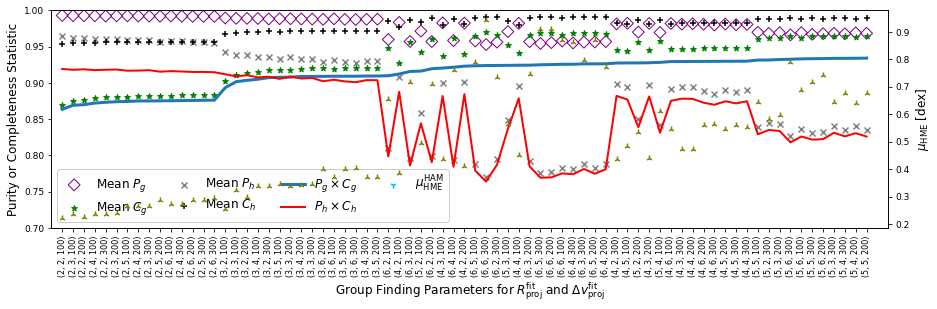

In [27]:
myrange=np.arange(1,len(pg)+1)
fig,ax=plt.subplots(figsize=(15,4))
ax.scatter(myrange-1,pg,edgecolors='purple',facecolors='None',marker='D',label='Mean $P_g$',s=70)
ax.scatter(myrange-1,cg,color='green',marker='*', label='Mean $C_g$')
ax.scatter(myrange-1,ph,color='gray',marker='x', label='Mean $P_h$')
ax.scatter(myrange-1,ch,color='k',marker='+', label='Mean $C_h$',s=30)
ax.plot(myrange-1,pgtimescg,color='tab:blue', linewidth=3,label=r'$P_g \times C_g$')
ax.plot(myrange-1,phtimesch,color='red',linewidth=2, label=r'$P_h \times C_h$')
ax.set_xticks(myrange-1,newlabels, rotation='vertical',fontsize=8)
ax.set_xlabel(r"Group Finding Parameters for $R_{\rm proj}^{\rm fit}$ and $\Delta v_{\rm proj}^{\rm fit}$",fontsize=12)
ax.set_ylim(0.7,1.0)
ax.set_xlim(-1,max(myrange)+1)
ax.set_ylabel("Purity or Completeness Statistic",fontsize=12)
ax1=ax.twinx()
#ax1.scatter(myrange-1,mu_phys,marker='1',color='deepskyblue',s=40,label=r'$\mu_{\rm HME}^{\rm HAM}$')
ax1.scatter(myrange-1,mu_dyn,marker='2',color='olive')
ax.scatter(-99,-99,marker='1',color='deepskyblue',s=40,label=r'$\mu_{\rm HME}^{\rm HAM}$')
ax1.set_ylabel(r'$\mu_{\rm HME}$ [dex]',fontsize=12)
#ax1.set_ylim(0.15,0.18)

ax.legend(loc='lower left', framealpha=1, fontsize=12, ncol=4)
plt.show()

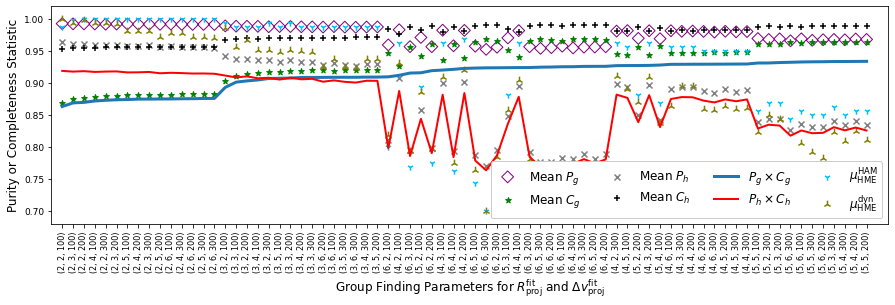

In [28]:
myrange=np.arange(1,len(pg)+1)
fig,ax=plt.subplots(figsize=(15,4))
ax.scatter(myrange-1,pg,edgecolors='purple',facecolors='None',marker='D',label='Mean $P_g$',s=70)
ax.scatter(myrange-1,cg,color='green',marker='*', label='Mean $C_g$')
ax.scatter(myrange-1,ph,color='gray',marker='x', label='Mean $P_h$')
ax.scatter(myrange-1,ch,color='k',marker='+', label='Mean $C_h$',s=30)
ax.plot(myrange-1,pgtimescg,color='tab:blue', linewidth=3,label=r'$P_g \times C_g$')
ax.plot(myrange-1,phtimesch,color='red',linewidth=2, label=r'$P_h \times C_h$')
ax.set_xticks(myrange-1,newlabels, rotation='vertical',fontsize=8)
ax.set_xlabel(r"Group Finding Parameters for $R_{\rm proj}^{\rm fit}$ and $\Delta v_{\rm proj}^{\rm fit}$",fontsize=12)
ax.set_ylim(0.7,1.0)
ax.set_xlim(-1,max(myrange)+1)
ax.set_ylabel("Purity or Completeness Statistic",fontsize=12)
#ax1=ax.twinx()
ax.scatter(myrange-1,mu,marker='1',color='deepskyblue',s=40,label=r'$\mu_{\rm HME}^{\rm HAM}$')
ax.scatter(myrange-1,mu_dyn_rank,marker='2',color='olive',s=60, label=r'$\mu_{\rm HME}^{\rm dyn}$')
#ax.scatter(-99,-99,marker='1',color='deepskyblue',s=40,label=r'$\mu_{\rm HME}^{\rm HAM}$')
#ax1.set_ylabel(r'$\mu_{\rm HME}$ [dex]',fontsize=12)
ax.set_ylim(0.68,1.02)
ax.legend(loc='lower right', framealpha=1, fontsize=12, ncol=4)
plt.show()